<a href="https://colab.research.google.com/github/tmacpherson6/investment_advisor_dashboard_capstone/blob/master/Kristine_SCF_Multiply_Imputed_Survey_Regression_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Survey of Consumer Finances (SCF) Financial Risk Tolerance Prediction**

In this notebook, we will be predicting a person's financial risk tolerance score using the features selected in a previous notebook through LASSO regression. We will be predicting variable **x7557**: a value from zero to ten, where zero is not at all willing to take risks and ten is very willing to take risks for each household respondent.

To ensure valid prediction, we will need to account for the following methodological features used in the SCF dataset:

1. **Complex Survey Design**: The SCF uses a dual frame design with a geographic national sample and list sample of wealthy people selected from IRS records. Each implicate includes 999 replicate weights constructed via balanced repeated replication (BRR), which enable design-consistent estimation of variance.

2. **Multiple Imputation**: The SCF addresses item nonresponse through multiple imputation. Each release includes five implicates—plausible, complete versions of the dataset with different imputed values for missing items.

In this notebook, we will use the **convey package** in R for analysis. We will utilize code from the following link as reference for constructing a multiply-imputed survey design: https://www.convey-r.org/1.6-survey-of-consumer-finances-scf.html#survey-of-consumer-finances-scf


### **Packages**

In [113]:
# Comment out if libraries below have already been installed
install.packages("haven")
install.packages("stringr")
install.packages("survey")
install.packages("mitools")
install.packages("convey")
install.packages("httr")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("glmnet")

library(haven)
library(stringr)
library(survey)
library(mitools)
library(convey)
library(httr)
library(dplyr)
library(ggplot2)
library(glmnet)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



### **Factor the categorical variables**

In [114]:
scf_list <- read.csv('/content/scf_list.csv')
scf_rw_df <- read.csv('/content/scf_rw_df.csv')

Add factors to represent categorical variables.

In [115]:
factor_vars <- c(
  "x401","x1301","x3103","x3913","x3923","x5711",
  "x5822","x5825","x6030","x6859","x7409","x7422",
  "x7558","x7650","x7761","x7775","hequity","edcl","x6670"
)

scf_list[factor_vars] <- lapply(scf_list[factor_vars], factor)

In [116]:
cols <- c("x414","x6556","x7198","x7556","x7561","x7562","x5729","x8300",
          "age","foodaway","reteq")
cols <- intersect(cols, names(scf_list))
scf_list[cols] <- lapply(scf_list[cols], function(x) {
  x[x == -1] <- 0
  x})

### **Split the datasets**

Create a list of dataframes for each of the 5 imputations - this will be used as an argument when constructing the survey design.

In [117]:
s1_df <- scf_list[str_sub(scf_list[, 'y1'] ,-1 ,-1) == 1 ,]
s2_df <- scf_list[str_sub(scf_list[, 'y1'] ,-1 ,-1) == 2 ,]
s3_df <- scf_list[str_sub(scf_list[, 'y1'] ,-1 ,-1) == 3 ,]
s4_df <- scf_list[str_sub(scf_list[, 'y1'] ,-1 ,-1) == 4 ,]
s5_df <- scf_list[str_sub(scf_list[, 'y1'] ,-1 ,-1) == 5 ,]

scf_list <- list(s1_df , s2_df , s3_df , s4_df , s5_df)

Missing data in the SCF has been imputed five times using a multiple imputation technique, meaning that each SCF family has 5 separate observations (implicates) in the data. We need to split the dataset by case ID so that each household and its imputations are either in the train or test sets.

In [118]:
set.seed(42)
train_frac <- 0.8

ids <- unique(scf_list[[1]]$yy1)

train_ids <- sample(ids, size = floor(train_frac * length(ids)))
test_ids  <- setdiff(ids, train_ids)

In [119]:
scf_train_list <- lapply(scf_list, \(d)d %>%
    filter(yy1 %in% train_ids) %>%
    select(-yy1, -y1))

scf_test_list <- lapply(scf_list, \(d)d %>%
    filter(yy1 %in% test_ids) %>%
    select(-yy1, -y1))

Split the replicate weights dataframe using the defined train and test IDs.

In [120]:
rw_train_list <- scf_rw_df %>%
  filter(yy1 %in% train_ids) %>%
  select(-yy1)

rw_test_list <- scf_rw_df %>%
  filter(yy1 %in% test_ids) %>%
  select(-yy1)

Plot the distribution of self-reported risk tolerance scores:

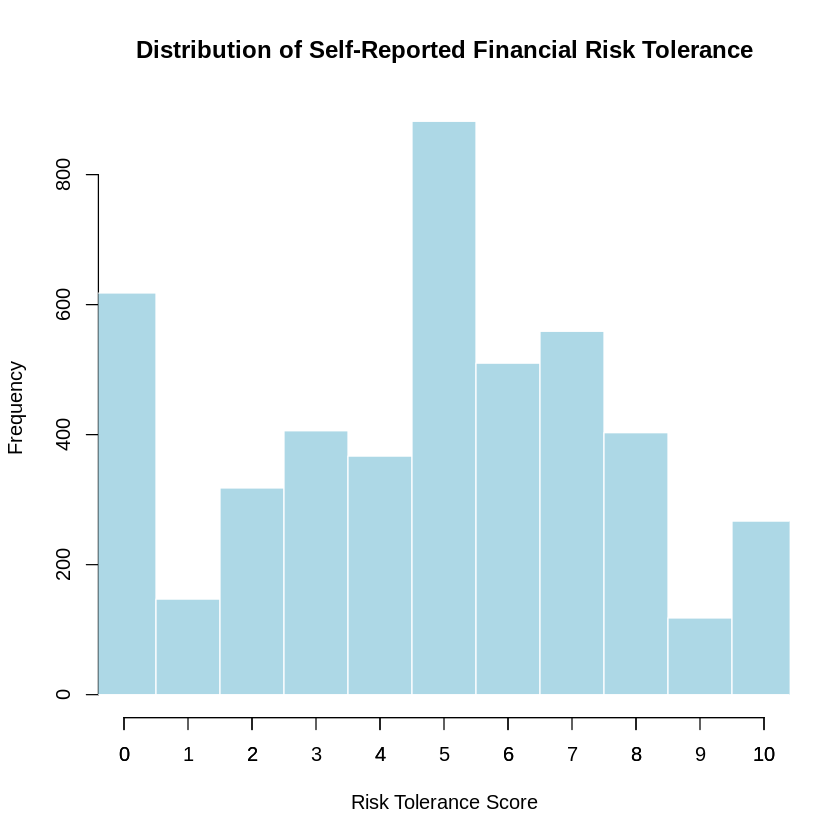

In [121]:
hist(
  scf_list[[1]]$x7557,
  breaks = seq(-0.5, 11, by = 1),
  xlim = c(0, 10),
  main = "Distribution of Self-Reported Financial Risk Tolerance",
  xlab = "Risk Tolerance Score",
  col = "lightblue",
  border = "white"
)
axis(1, at = 0:10)

### **Construct the Multiply-Imputed Complex Survey Design**

Create a helper function specific to the scf dataset, based off of the MIcombine function from the **mitools** package for multiple imputation inference.

In [122]:
scf_MIcombine <-
  function (results,
            variances,
            call = sys.call(),
            df.complete = Inf,
            ...) {
    m <- length(results)
    oldcall <- attr(results, "call")
    if (missing(variances)) {
      variances <- suppressWarnings(lapply(results, vcov))
      results <- lapply(results, coef)
    }
    vbar <- variances[[1]]
    cbar <- results[[1]]
    for (i in 2:m) {
      cbar <- cbar + results[[i]]
    }
    cbar <- cbar / m
    evar <- var(do.call("rbind", results))
    r <- (1 + 1 / m) * evar / vbar
    df <- (m - 1) * (1 + 1 / r) ^ 2
    if (is.matrix(df))
      df <- diag(df)
    if (is.finite(df.complete)) {
      dfobs <- ((df.complete + 1) / (df.complete + 3)) * df.complete *
        vbar / (vbar + evar)
      if (is.matrix(dfobs))
        dfobs <- diag(dfobs)
      df <- 1 / (1 / dfobs + 1 / df)
    }
    if (is.matrix(r))
      r <- diag(r)
    rval <- list(
      coefficients = cbar,
      variance = vbar + evar *
        (m + 1) / m,
      call = c(oldcall, call),
      nimp = m,
      df = df,
      missinfo = (r + 2 / (df + 3)) / (r + 1)
    )
    class(rval) <- "MIresult"
    rval
  }

Define the survey design, then run the convey_prep() function to set the population of reference.

In [123]:
scf_train_design <-
  svrepdesign(
    weights = ~ wgt ,
    repweights = rw_train_list,
    data = imputationList(scf_train_list),
    scale = 1 ,
    rscales = rep(1 / 998 , 999),
    mse = FALSE,
    type = "other",
    combined.weights = TRUE
  )

scf_train_design$designs <- lapply(scf_design$designs , convey_prep)

In [129]:
scf_test_design <- svrepdesign(
  weights = ~wgt,
  repweights = rw_test_list,
  data = imputationList(scf_test_list),
  scale = 1,
  rscales = rep(1/998, 999),
  mse = FALSE,
  type = "other",
  combined.weights = TRUE
)

scf_test_design$designs <- lapply(scf_test_design$designs, convey_prep)

Drop unused factor levels in the design

In [124]:
scf_design$variables <- droplevels(as.data.frame(scf_design$variables))

### **Prediction and Evaluation**

In [125]:
predictors <- c(
  'age','married','hhsex','hequity','edcl','x6670','x8300',
  'x401','x414','x435','x3023','x3103','x3913','x7489',
  'x5913','x5824','x5824','x6556','x6789','x7364','x7562',
  'x7556','x7558','x7558','x7650'
)

form <- reformulate(predictors, response = "x7557")

In [ ]:
train_designs <- scf_design$designs
test_designs  <- scf_test_design$designs

fits <- lapply(train_designs, function(d) svyglm(form, design = d))

In [131]:
preds <- Map(function(fit, dtest) {
  predict(fit, newdata = dtest$variables, type = "response")
}, fits, test_designs)

In [138]:
wtd_rmse <- function(y, yhat, w) sqrt( sum(w*(y - yhat)^2, na.rm=TRUE) / sum(w, na.rm=TRUE) )
wtd_mae  <- function(y, yhat, w)       sum(w*abs(y - yhat), na.rm=TRUE) / sum(w, na.rm=TRUE)

metrics_imp <- Map(function(dtest, yhat) {
  y <- dtest$variables$x7557
  w <- weights(dtest)              # full-sample weights
  c(rmse = wtd_rmse(y, yhat, w),
    mae  = wtd_mae(y, yhat, w))
}, scf_test_design$designs, preds)

metrics_imp <- do.call(rbind, metrics_imp)
colMeans(metrics_imp, na.rm = TRUE)

rmse      mae 
2.306635 1.823570

In [ ]:
glm_result <-
  scf_MIcombine(with(scf_design,
  svyglm(reformulate(termlabels = predictors, response = "x7557"))))

In [139]:
est <- glm_result$coefficients
se  <- sqrt(diag(glm_result$variance))

z <- est / se
p <- 2 * pnorm(abs(z), lower.tail = FALSE)

p_table <- data.frame(
  term = names(est),
  estimate = unname(est),
  se = unname(se),
  z = unname(z),
  p_value = unname(p)
)

p_table[order(p_table$p_value), ]

,term,estimate,se,z,p_value
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Intercept),5.579604e+00,5.278554e-01,10.5703268,4.090667e-26
31,x7562,9.615812e-02,1.256516e-02,7.6527599,1.967109e-14
29,x6789,-1.916224e-01,2.694714e-02,-7.1110488,1.151644e-12
4,hhsex,-8.584496e-01,1.225507e-01,-7.0048548,2.472421e-12
3,married,7.024526e-01,1.079749e-01,6.5057010,7.733188e-11
2,age,-2.073547e-02,3.219515e-03,-6.4405567,1.190361e-10
24,x39135,-4.884149e-01,9.433484e-02,-5.1774601,2.249271e-07
20,x414,5.799534e-06,1.179497e-06,4.9169540,8.790121e-07
22,x3023,1.814653e-01,3.693168e-02,4.9135400,8.944648e-07


In [ ]:
f_zero <- reformulate(predictors, response = "I(x7557 == 0)")
f_pos  <- reformulate(predictors, response = "log1p(x7557)")

hurdle_fits <- lapply(scf_design$designs, function(d) {
  fit_zero <- svyglm(f_zero, design = d, family = quasibinomial())

  d_pos <- subset(d, x7557 > 0)
  fit_pos <- svyglm(f_pos, design = d_pos)

  list(fit_zero = fit_zero, fit_pos = fit_pos)
})

hurdle_preds <- Map(function(fits, dtest) {
  newdat <- dtest$variables

  p0 <- predict(fits$fit_zero, newdata = newdat, type = "response")

  mu_log <- predict(fits$fit_pos, newdata = newdat, type = "response")

  mu_pos <- expm1(mu_log)
  yhat   <- (1 - p0) * mu_pos
  yhat   <- pmin(pmax(yhat, 0), 10)

  yhat
}, hurdle_fits, scf_test_design$designs)

wtd_rmse <- function(y, yhat, w) sqrt(sum(w*(y-yhat)^2, na.rm=TRUE) / sum(w, na.rm=TRUE))
wtd_mae  <- function(y, yhat, w)      sum(w*abs(y-yhat), na.rm=TRUE) / sum(w, na.rm=TRUE)

metrics_imp <- Map(function(dtest, yhat) {
  y <- dtest$variables$x7557
  w <- weights(dtest)
  c(rmse = wtd_rmse(y, yhat, w),
    mae  = wtd_mae (y, yhat, w))
}, scf_test_design$designs, hurdle_preds)

metrics_imp <- do.call(rbind, metrics_imp)
colMeans(metrics_imp, na.rm = TRUE)

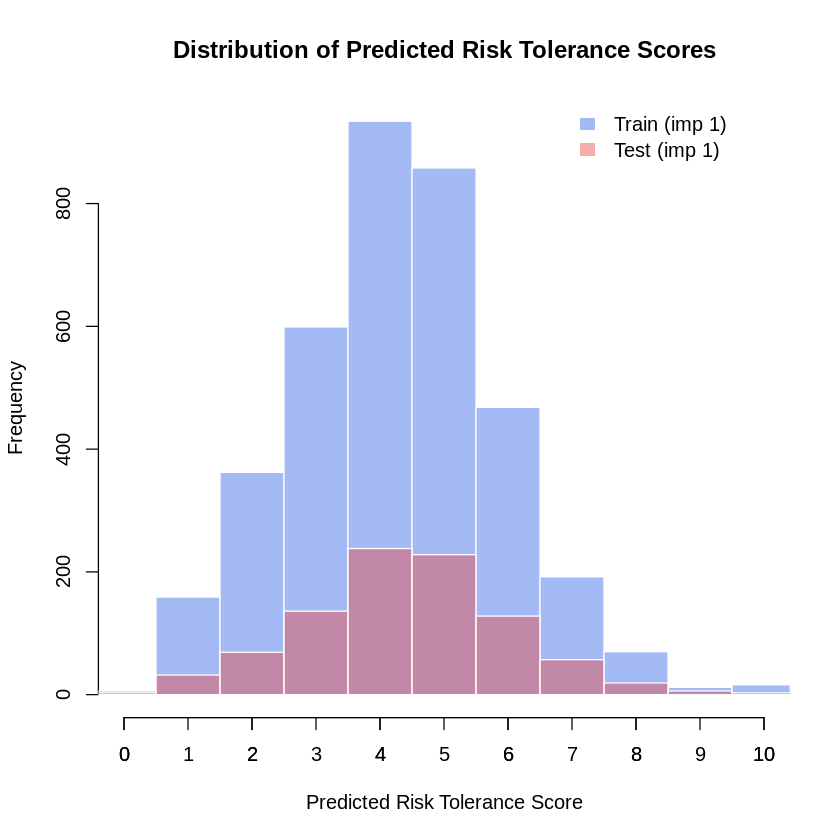

In [141]:
predict_hurdle <- function(fits, design_obj) {
  newdat <- design_obj$variables

  p0 <- predict(fits$fit_zero, newdata = newdat, type = "response")
  mu_log <- predict(fits$fit_pos, newdata = newdat, type = "response")

  yhat <- (1 - p0) * expm1(mu_log)
  pmin(pmax(yhat, 0), 10)
}

train_pred_1 <- predict_hurdle(hurdle_fits[[1]], scf_design$designs[[1]])
test_pred_1  <- predict_hurdle(hurdle_fits[[1]], scf_test_design$designs[[1]])

breaks <- seq(-0.5, 10.5, by = 1)

hist(
  train_pred_1,
  breaks = breaks,
  xlim = c(0, 10),
  main = "Distribution of Predicted Risk Tolerance Scores",
  xlab = "Predicted Risk Tolerance Score",
  col = rgb(0.2, 0.4, 0.9, 0.45),
  border = "white"
)

hist(
  test_pred_1,
  breaks = breaks,
  add = TRUE,
  col = rgb(0.9, 0.3, 0.3, 0.45),
  border = "white"
)

axis(1, at = 0:10)
legend(
  "topright",
  legend = c("Train (imp 1)", "Test (imp 1)"),
  fill = c(rgb(0.2, 0.4, 0.9, 0.45), rgb(0.9, 0.3, 0.3, 0.45)),
  border = NA,
  bty = "n"
)